# Морфологический анализ

Сначала нам нужно немного вспомнить что такое функции и узнать что такое классы!

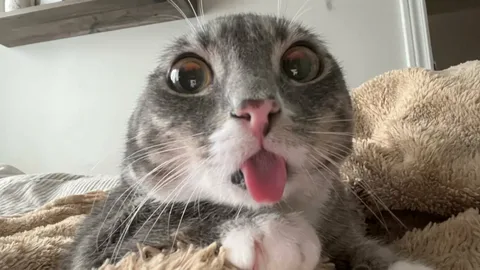

> Сейчас будет немного простого Python

In [17]:
def say_meow():
    print('Meow!')

say_meow()
say_meow()
say_meow()

Meow!
Meow!
Meow!


In [23]:
# Класс -> объект (конкретная реализация класса, конкретный экземпляр)
class Cat:
    def __init__(self, color, name):
        self.has_tail = True
        self.legs = 4
        self.color = color
        self.name = name

    def say_hello(self):
        print(f"Кот по имени {self.name} говорит: МЯЯУ!")

cat1 = Cat(color='рыжий', name="Вася")
cat2 = Cat(color='cерый', name="Барсик")
print(cat1.color)
cat1.say_hello()
cat2.has_tail = False
cat2.legs = 8
print(cat2.legs)

рыжий
Кот по имени Вася говорит: МЯЯУ!
8


In [ ]:
class Kitty(Cat):
    def __init__(self, color, name):
        super().__init__(color, name)
        self.маленькость = 0.01


In [25]:
c = Kitty(color='рыжий', name="Кот в сапогах!")
c.say_hello()

Кот по имени Кот в сапогах! говорит: МЯЯУ!


## Что такое морфологический анализ?

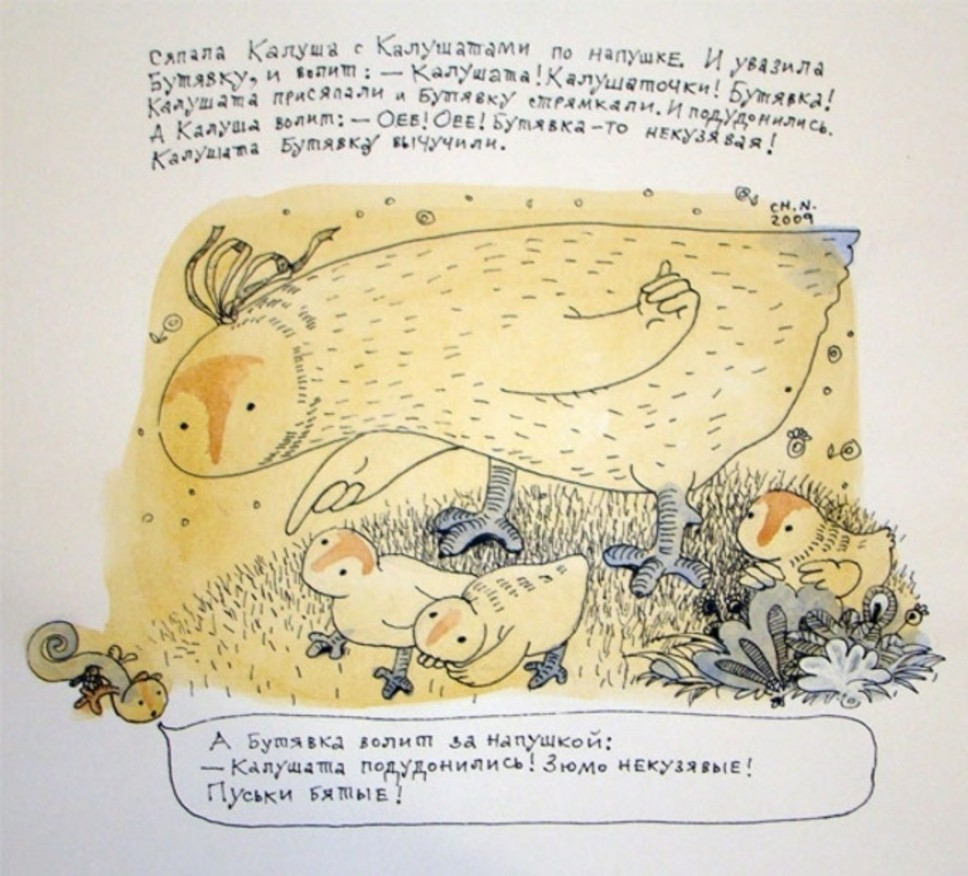

`Морфологический анализ` — это процесс автоматического определения грамматических характеристик словоформы в тексте. В вычислительной лингвистике он решает три взаимосвязанные задачи:

```
Вход: словоформа в контексте → "студентами"
Выход:
  • Лемма: "студент"
  • Часть речи: NOUN (существительное)
  • Грамматические признаки: 
    - одушевлённость: anim
    - род: masc
    - число: plur
    - падеж: ablt (творительный)
```

Ключевые компоненты:

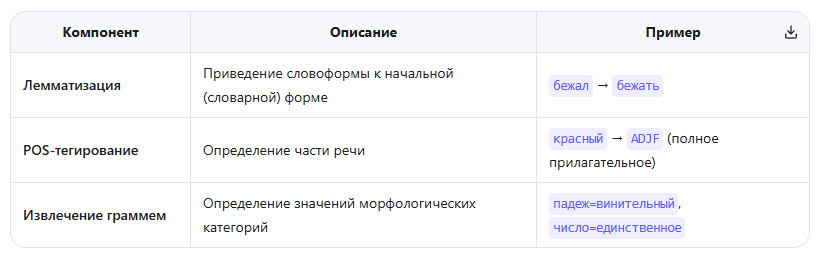

Простой пример на `pymorphy3`

In [26]:
import pymorphy3

morph = pymorphy3.MorphAnalyzer()
word = "студентами"
parse = morph.parse(word)[0]  # Наиболее вероятный разбор

print(f"Словоформа: {word}")
print(f"Лемма: {parse.normal_form}")
print(f"Часть речи: {parse.tag.POS}")
print(f"Падеж: {'ablt' in parse.tag.grammemes and 'творительный' or 'другой'}")
print(f"Число: {'plur' in parse.tag.grammemes and 'множественное' or 'единственное'}")
print(f"Уверенность: {parse.score:.3f}")

Словоформа: студентами
Лемма: студент
Часть речи: NOUN
Падеж: творительный
Число: множественное
Уверенность: 1.000


## Роль морфологии в вычислительной лингвистике

Морфологический анализ (морфологическая разметка) решает задачу автоматического определения грамматических характеристик словоформы в тексте. В контексте обработки естественного языка (NLP) он выполняет три функции:
1. **Лемматизация** – приведение словоформы к словарной начальной форме.
2. **POS-тегирование** – определение части речи.
3. **Извлечение граммем** – извлечение значений падежа, числа, рода, времени, вида, наклонения, лица, одушевлённости и других категорий.

С точки зрения машинного обучения морфологический анализ является критическим этапом инженерии признаков. Он позволяет:


* Сократить размерность пространства признаков (сведение `бежал`, `бегу`, `бегать` к одной лексеме `бежать`).
* Извлекать интерпретируемые лингвистические признаки для задач стилометрии, авторской атрибуции, жанровой классификации и анализа тональности.
* Улучшать качество моделей за счёт учёта грамматической структуры, особенно в языках с богатой морфологией, таких как русский.

## PyMorphy

### Базовый разбор слова



In [35]:
import pymorphy3

morph = pymorphy3.MorphAnalyzer()

# Разбор возвращает список Parse-объектов, отсортированных по вероятности
word = "бежали"
parses = morph.parse(word)

print(f"Слово: {word}")
print(f"Количество вариантов: {len(parses)}")
for i, p in enumerate(parses, 1):
    print(f"{i}. Лемма: {p.normal_form:<12} | Тег: {str(p.tag):<30} | Вероятность: {p.score:.4f}")

Слово: бежали
Количество вариантов: 2
1. Лемма: бежать       | Тег: VERB,perf,intr plur,past,indc  | Вероятность: 0.5000
2. Лемма: бежать       | Тег: VERB,impf,intr plur,past,indc  | Вероятность: 0.5000


### Работа с тегами и грамматическими категориями

In [31]:
import pymorphy3

morph = pymorphy3.MorphAnalyzer()
p = morph.parse("котятами")[0]

print(f'Начальная форма: {p.normal_form}' )
# Доступ к части речи
print(f"POS: {p.tag.POS}")

# Проверка наличия конкретных граммем
print(f"Творительный падеж: {'ablt' in p.tag.grammemes}")
print(f"Множественное число: {'plur' in p.tag.grammemes}")

# Циклическая кириллическая репрезентация
print(f"Кириллический тег: {p.tag.cyr_repr}")

Начальная форма: котёнок
POS: NOUN
Творительный падеж: True
Множественное число: True
Кириллический тег: СУЩ,од,мр мн,тв


### Словоизменение (инфлексия)

`pymorphy3` позволяет генерировать словоформы по заданным грамматическим характеристикам через метод `inflect()`.

In [36]:
import pymorphy3

morph = pymorphy3.MorphAnalyzer()
p = morph.parse("быстрый")[0]

# Генерация форм: женский род, творительный падеж, единственное число
new_form = p.inflect({'femn', 'ablt', 'sing'})
if new_form:
    print(f"Быстрый -> {new_form.word}")  # быстрой
else:
    print("Форма не найдена (невалидная комбинация граммем)")

Быстрый -> быстрой


### Обработка неизвестных слов

Если слово отсутствует в словаре, `pymorphy3` пытается восстановить лемму по правилам продуктивных словоизменительных классов. Вероятность такого разбора обычно ниже. Рекомендуется фильтровать результаты по `score > 0.5` или проверять `p.methods_stack` на наличие словарных методов.

In [51]:
import pymorphy3

morph = pymorphy3.MorphAnalyzer()
word = "котятами"
parse = morph.parse(word)
for res in parse:
    print(res)

parse[0].tag

Parse(word='котятами', tag=OpencorporaTag('NOUN,anim,masc plur,ablt'), normal_form='котёнок', score=1.0, methods_stack=((DictionaryAnalyzer(), 'котятами', 205, 10),))


OpencorporaTag('NOUN,anim,masc plur,ablt')

### Проблема омонимии

Словоформы часто имеют несколько возможных разборов. `ключ` может быть существительным или кратким прилагательным. `pymorphy3` ранжирует варианты по эмпирическим вероятностям, вычисленным на размеченных корпусах. Наиболее вероятный разбор всегда возвращается первым.

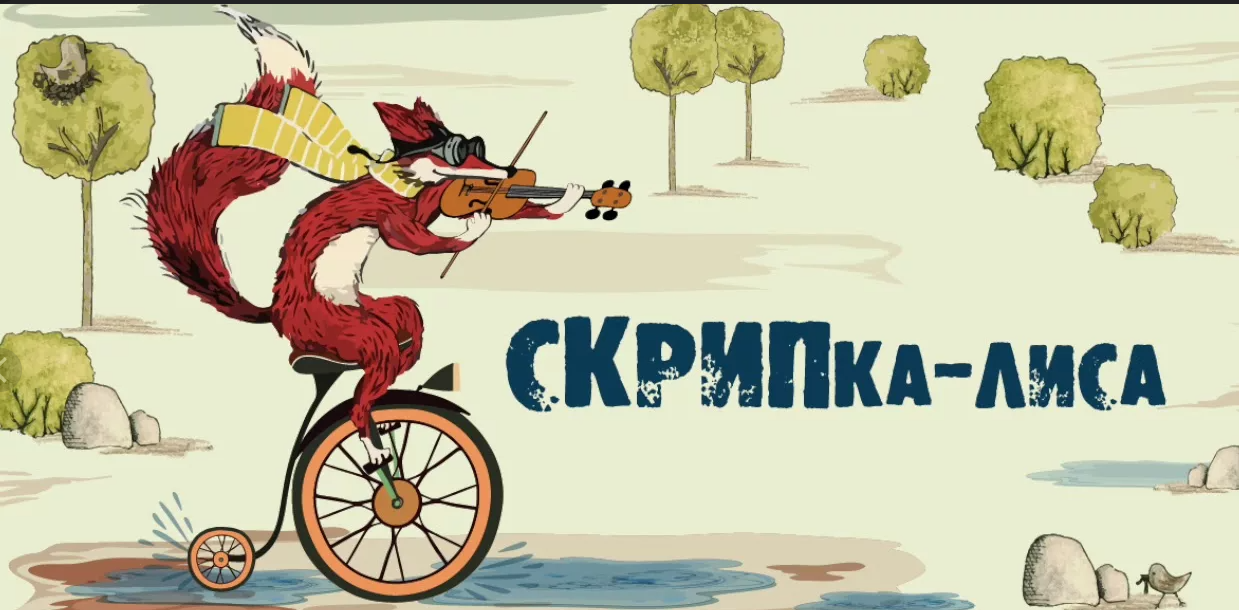

### Практический пример: Пайплайн морфологического анализа текста

In [44]:
import re
import csv
from collections import Counter, defaultdict
from typing import List, Dict, Tuple
import pymorphy3

In [45]:
Counter('abracadabra')

Counter({'a': 5, 'b': 2, 'r': 2, 'c': 1, 'd': 1})

In [52]:
class MorphologyAnalyzer:
    def __init__(self):
        self.morph = pymorphy3.MorphAnalyzer()
        # Служебные части речи для фильтрации
        self.stop_pos = {'PREP', 'CONJ', 'PRCL', 'INTJ'}

    def tokenize(self, text: str) -> List[str]:
        """Простая токенизация с сохранением кириллицы и латиницы."""
        return re.findall(r'[а-яёa-zА-ЯЁA-Z]+', text)

    def analyze_text(self, text: str) -> List[Dict]:
        """Разбор текста: возврат списка словарей с морфологической разметкой."""
        tokens = self.tokenize(text)
        results = []

        for token in tokens:
            parses = self.morph.parse(token)
            if not parses:
                continue

            best_parse = parses[0]
            tag = best_parse.tag

            results.append({
                "token": token,
                "lemma": best_parse.normal_form,
                "pos": tag.POS,
                "case": self._get_gramme(tag, {'nomn', 'gent', 'datv', 'accs', 'ablt', 'loct'}),
                "number": self._get_gramme(tag, {'sing', 'plur'}),
                "gender": self._get_gramme(tag, {'masc', 'femn', 'neut'}),
                "tense": self._get_gramme(tag, {'pres', 'past', 'futr'}),
                "confidence": best_parse.score
            })

        return results

    def _get_gramme(self, tag, grammes_set: set) -> str:
        """Извлекает первую попавшуюся грамему из множества или возвращает None."""
        intersection = tag.grammemes.intersection(grammes_set)
        return next(iter(intersection), None)

    def compute_statistics(self, analysis: List[Dict]) -> Dict[str, float]:
        """Агрегирует статистику по частям речи и грамматическим категориям."""
        total = len(analysis)
        if total == 0:
            return {}

        pos_counts = Counter(item["pos"] for item in analysis)
        pos_distribution = {pos: count / total for pos, count in pos_counts.items()}

        # Доля содержательных частей речи
        content_pos = {"NOUN", "VERB", "ADJF", "ADJS", "ADV", "INFN"}
        content_ratio = sum(pos_distribution.get(p, 0) for p in content_pos)

        # Лексическое разнообразие (отношение уникальных лемм к общему числу слов)
        unique_lemmas = len(set(item["lemma"] for item in analysis))
        lexical_diversity = unique_lemmas / total if total > 0 else 0.0

        return {
            "pos_distribution": pos_distribution,
            "content_words_ratio": content_ratio,
            "lexical_diversity": lexical_diversity,
            "total_tokens": total,
            "avg_confidence": sum(item["confidence"] for item in analysis) / total
        }

def save_to_csv(analysis: List[Dict], filepath: str):
    """Экспорт результатов в CSV для последующего анализа в pandas/R."""
    if not analysis:
        return
    fieldnames = analysis[0].keys()
    with open(filepath, "w", encoding="utf-8", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(analysis)

In [ ]:
analyzer = MorphologyAnalyzer()

sample_text = """
Исследователи из Уральского федерального университета представили новую модель машинного обучения. Они назвали её ... .
Алгоритмы обрабатывали большие текстовые корпуса с высокой скоростью.
Лингвисты оценили точность морфологической разметки и предложили улучшения для анализа омонимии.
"""

# 1. Анализ
results = analyzer.analyze_text(sample_text)

# 2. Статистика
stats = analyzer.compute_statistics(results)
print("Статистика текста:")
print(f"  Токенов: {stats['total_tokens']}")
print(f"  Лексическое разнообразие: {stats['lexical_diversity']:.3f}")
print(f"  Доля содержательных слов: {stats['content_words_ratio']:.3f}")
print(f"  Средняя уверенность разбора: {stats['avg_confidence']:.3f}")
print("  Распределение POS:", {k: round(v, 3) for k, v in stats['pos_distribution'].items()})

# 3. Сохранение
save_to_csv(results, "morph_analysis_output.csv")
print("\nРезультаты сохранены в morph_analysis_output.csv")

Статистика текста:
  Токенов: 29
  Лексическое разнообразие: 1.000
  Доля содержательных слов: 0.862
  Средняя уверенность разбора: 0.800
  Распределение POS: {'NOUN': 0.448, 'PREP': 0.103, 'ADJF': 0.276, 'VERB': 0.138, 'CONJ': 0.034}

Результаты сохранены в morph_analysis_output.csv


In [54]:
import pandas as pd

pd.read_csv('morph_analysis_output.csv')

,token,lemma,pos,case,number,gender,tense,confidence
0,Исследователи,исследователь,NOUN,nomn,plur,masc,NaN,1.000000
1,из,из,PREP,NaN,NaN,NaN,NaN,0.999673
2,Уральского,уральский,ADJF,gent,sing,masc,NaN,0.500000
3,федерального,федеральный,ADJF,gent,sing,neut,NaN,0.641304
4,университета,университет,NOUN,gent,sing,masc,NaN,1.000000
5,представили,представить,VERB,NaN,plur,NaN,past,1.000000
6,новую,новый,ADJF,accs,sing,femn,NaN,1.000000
7,модель,модель,NOUN,nomn,sing,femn,NaN,0.810810
8,машинного,машинный,ADJF,gent,sing,neut,NaN,0.500000
9,обучения,обучение,NOUN,gent,sing,neut,NaN,0.968253


# Часть 1. Базовая
* Установите pymorphy3 и numpy.
* Загрузите любой русскоязычный текст объёмом 1000-2000 слов (художественный или публицистический).
* Реализуйте скрипт, который:
    * Проводит лемматизацию всего текста.
    * Строит частотный словарь лемм, отфильтровывая служебные части речи (предлоги, союзы, частицы).
    * Выводит топ-15 наиболее частотных содержательных лемм.
* Ответьте письменно (3-4 предложения): какие леммы доминируют и как это соотносится с жанром текста?

# Часть 2. Сравнительный анализ 
* Возьмите 25 предложений с неоднозначными словоформами (например, мой, стекло, красный, бежал, ключ).
* Разберите их через pymorphy3
* Рассчитайте метрику совпадения POS-тегов: accuracy.
* Выпишите 5 примеров, где модели разошлись. Объясните расхождение с точки зрения контекста.

мой (гл) -> мой (мест)
кошка (сущ., неод) -> кошка(сущ., од.)
кошка(сущ., од.) -> кошка(сущ., од.)
замок(сущ., неод) -> замок(гл)
мой (гл) -> мой (гл)

2 / 5

In [3]:
A = int(input())
B = int(input())
C = int(input())
D = int(input())

if A == C and B + D == A or A == D and B + C == A or B == C and A + D == B or B == D and A + C == B:
    print("SQUARE")
elif A == C or A == D or B == C or B == D:
    print("RECTANGLE")
else:
    print(":(")

:(


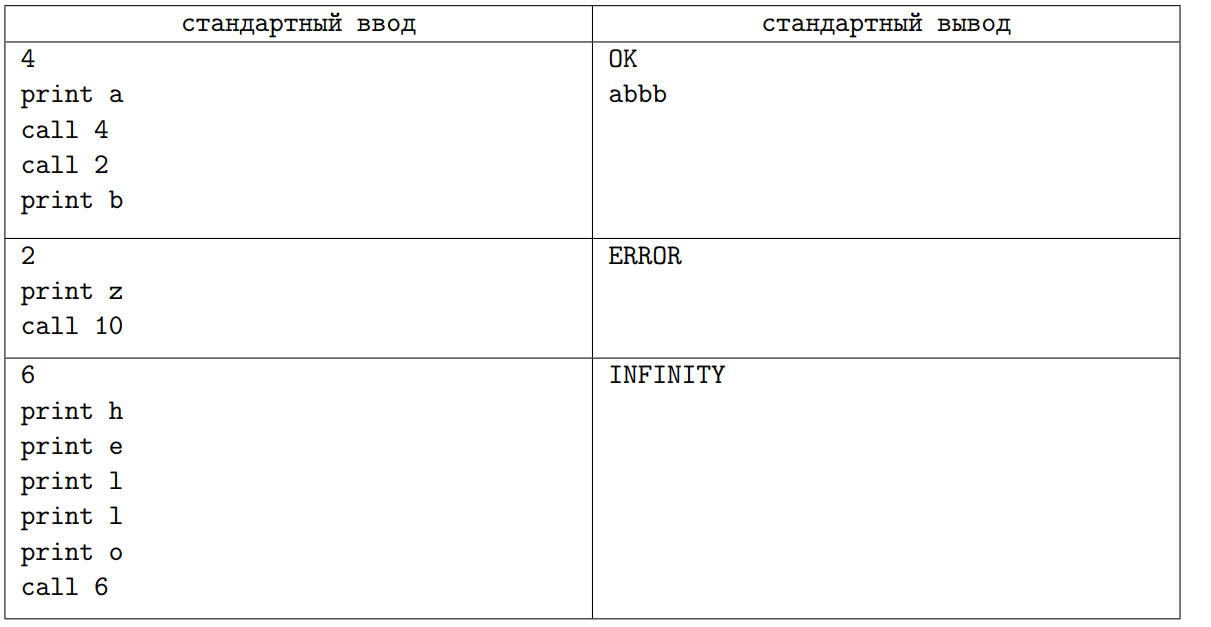

In [4]:
# [ip, cmd, arg]
n = int(input())
program = []
for ip in range(n):
    cmd, arg = input().split()
    program.append((ip, cmd, arg))

for line in program:
    print(*line)

0 print a
1 call 4
2 call 2
3 print b
